# 3D Poisson Notebook

Calculates Poisson ratios by applying forces to edges.

In [2]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

# def extents(result,frame=0):
#     Nbeads = int(np.max(result.dump_id[frame])/2)
#     botmask = result.dump_id[frame]<=(Nbeads)
#     topmask = result.dump_id[frame]>(Nbeads)
#     ytopavg = np.mean(result.dump_y[frame][topmask])
#     ybotavg = np.mean(result.dump_y[frame][botmask])
#     xmax = np.max(result.dump_x[frame])
#     xmin = np.min(result.dump_x[frame])
#     x = xmax-xmin
#     y = ytopavg-ybotavg
#     return (x,y)

# Run MD

In [71]:
np.sqrt(2/5)

0.6324555320336759

In [100]:
tstart = time.time()
stretch = "x"  # stretch direction ("x", "y", or "z")
t0_list = [1.0]    # independent jobs that run in parallel (must be list)
force_list =  np.linspace(0.01,0.501,30).tolist()    # dependent jobs that run in series (must be list)

jobcounter = 0
for i in range(len(t0_list)):   
    
    simcounter = 0
    jobcounter += 1
    
    print("#####################################\n")
    print(f"Setting up job {jobcounter}...")
    
    series_simpaths = [] # append simpaths that will run in series for each job (i.e. different kh values)
    
    for j in range(len(force_list)):  
        
        simcounter += 1
        
        print(f"----Preparing simulation {simcounter}...")

        ##### PARTICLE #####
        ### Geometry
        dimension = 3
        dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
        wx = 15 * dcore    # mesh width in x 
        wy = 15 * dcore    # mesh width in y 
        a = 0.632 * dcore    # lattice constant of mesh
        mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
        t0 = t0_list[i]    # structural thickness
        r0 = "flat"   # RMS radius of curvature; set to "flat" for planar plates 
        alpha = 0    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
        theta = 0    # angle principal direction 1 makes with material x-axis

        if r0 == "flat":
            k_0 = 0
        else:
            k_0 = 1/r0    # RMS curvature
        
        # preferred curvatures
        k01 = k_0 * np.cos(alpha)    # principal curvatures
        k02 = k_0 * np.sin(alpha)
        kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
        ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
        kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)
        

        ### Elasticity
        kh = 1
        nuxy = 0.33
        nuz = 0.01
        kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
        kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 
        
        # 2D equations
#         nu = 0.3
#         d = wx/(Nbeads-1)   # bead spacing
#         kvkh = (12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
#         kckh = (3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)

        ### Interactions
        pair_ints = "none" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
        soft_ints = False
        sigma = 1*dcore
        epsilon = 0.0044
        shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
        ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
        wcacut = dcore    # cutoff distance for repulsive wca potential
        softsigma = 5*sigma
        softepsilon = 5e-8 * epsilon
        softshift = 0 #softcore - 2**(1/6)*softsigma
        softcut = 2**(1/6) * softsigma

        ##### SIMULATION #####
        config = "stacked" #"dispersed" or "stacked"
        simtype = "md"
        datascript = "stack3D"    # script to make data file with, NO .py EXTENSION, "stack3D", "load3D", or "lattice3D"
        nshells = 1
        datagz = True
        trajgz = True
        dumpbonds = False    # whether to calculate and dump bond data
        screen = True    # output lammps log to screen


        ### Stacked config settings
        ki1 = 0 * k01    # principal curvatures for bottom shell in stack
        ki2 = 0 * k02
        theta_i = theta
        kx_i = ki1 * np.cos(theta_i)**2 + ki2 * np.sin(theta_i)**2  # curvatures in material directions x, y, xy
        ky_i = ki1 * np.sin(theta_i)**2 + ki2 * np.cos(theta_i)**2
        kxy_i = (ki1-ki2) * np.sin(theta_i) * np.cos(theta_i)
        xlo = -2*wx
        xhi = 2*wx
        ylo = -2*wy
        yhi = 2*wy
        if r0 != 'flat':
            zlo = -4*r0
            zhi = nshells*r0 + 4*r0
        else:
            zlo = -5*(t0+dcore)
            zhi = nshells*(t0+dcore) + 5*(t0+dcore)

        ### Lattice config settings
#         Nx = 2    # number of particle columns for initial config 
#         Ny = int(nshells/Nx)
#         nshells = int(Nx*Ny)   # true number of shells in simulation
#         k_i = 0    # initial curvature of shells in lattice (need flat for high concentrations)
#         theta = "random"   # orientation of shells in lattice (0 = concave down, np.pi = concave up, "random" = randomly up or down)

        ### Dispersed config settings
#         phi = 0.1    # concentration of molecules (area fraction) - only for MD
#         v0 = wx * (t0 + dcore)    # approx area of monomer
#         lbox = np.sqrt(nshells * v0 / phi)    # side length of (square) sim box to give proper concentration
#         xlo = -lbox/2
#         xhi = lbox/2
#         ylo = -lbox/2
#         yhi = lbox/2
#         zlo = -0.5
#         zhi = 0.5

        ### Dynamics/Minimization Settings
#         minstyle = "cg"
#         etol = 1e-12
#         maxiter = 100000

        Tstart = 0
        Tstop = Tstart
        Tdamp = 1
        seed = 15298
        timestep = 0.0005
        runsteps = 1000000

        dumpfreq = 100000
        thermofreq = 1000

        force  = force_list[j]

        ##### LOGISTICS #####

        ### Simulation Directories
        delete_existing = True    # if True, deletes simulation directory (and .sh files) if it exists before creating again
        simpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/stretch-{stretch}/kh-{kh:0.3f}/force-{force:0.4f}"
        load_simpath = False # location of simulation to load in (set to False if not loading in state)
#         load_simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh_load:0.2f}/nshells-{nshells}" # location of simulation to load in (set to False if not loading in state)
#         load_dumpname = -1 # name of trajectory file to load (-1 selects highest integer found, e.g trajectory2.dump)
#         load_frame = -1    # frame number to load in (not timestep! 0 is initial state; -1 is last completed dump)

        ### Computation
        computer = "local"
#         computer = "unity"
        nnodes = 1
        mem = 1 #GB
        tlim_hrs = 1
        tlim_min = 0
        partition = "cpu-preempt"    # requested partition
        jobname = os.path.splitext(os.path.basename(sys.argv[0]))[0]
        requested_walltime = f'{tlim_hrs:02d}:{tlim_min:02d}:00'
        tbuffer = 5 # stop lammps tbuffer minutes before walltime is exceeded
                        # any non-zero value means script will auto resubmit until done
                        # zero means no auto resubmission - job stops when done or if time is exceeded
        px = 2    # number of cpus along x
        py = 2
        pz = 1
        gridfreq = 10000    # check cpu partitioning of simbox every gridfreq steps
        thresh = 1.01    # threshold imbalance to repartition simbox
        maxrestarts = 10    # max number of runs for one job (cluster only, local machine limit is set below to 5)

        # add tstep start variable?
        
        
        #################
        ##### SETUP #####
        #################
        
        print("--------Creating simulation directory...")
        
        ### Make simulation directory
        
        if delete_existing == True:
            if os.path.isdir(f"{PROJECT_ROOT}/{simpath}"):
                print("""----------Simulation directory already exists.
----------Deleting...""")
                shutil.rmtree(f"{PROJECT_ROOT}/{simpath}")
                print("----------Creating new simulation directory...")
        
        os.makedirs(f"{PROJECT_ROOT}/{simpath}", exist_ok=True)
        
        ### Append simpaths to job status file and to series_simpaths
#         print("--------Adding simulation directory to job simpaths file...")
#         rm.update_simpaths_file(JOBDIR,JOB,simpath)
        series_simpaths.append(simpath)

        ###############################
        ##### LAMMPS INPUT SCRIPT #####
        ###############################

        print("--------Writing LAMMPS input file...")
        
        ### Header
        inputcontents = f"""# Coarse-grained shell model - LAMMPS input file
        
units lj
dimension {dimension}
boundary s s s
atom_style molecular
bond_style harmonic
angle_style none
dihedral_style none
improper_style none

processors {px} {py} {pz} grid onelevel

comm_style tiled
"""

        if datagz==True:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps.gz"

"""
        else:
            inputcontents +="""
variable restart_exists equal is_file(restart.final)
if "${restart_exists}" then "read_restart restart.final" else "read_data data.lammps"

"""
        
        ### Interactions
        if pair_ints == "none":
            inputcontents += "pair_style none"
#         elif pair_ints == "repulsive":
#             inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# \n
# """
            
#         else:
#             if soft_ints == True:
#                 inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 3 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 1 3 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 4 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# pair_coeff 2 4 lj/expand {softepsilon} {softsigma} {softshift} {softcut-softshift}
# """
#             else:
#                 inputcontents += f"""
# pair_style hybrid lj/expand {ljcut}
# # upside down bonding 1
# pair_coeff 1 1 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 3 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 1 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# # upside down bonding 2
# pair_coeff 2 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 4 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# """

        
#             if pair_ints == "1patch":
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {wcacut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# """
#             elif pair_ints == "patchy":
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {wcacut-shift}
# pair_modify shift yes
# \n
# """
                
#             elif pair_ints == "attractive":
#                 inputcontents += f"""
# # correct bonding
# pair_coeff 1 2 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # edge-edge
# pair_coeff 3 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift} # center-center
# pair_coeff 1 4 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
# pair_coeff 2 3 lj/expand {epsilon} {sigma} {shift} {ljcut-shift}
# pair_modify shift yes
# \n
# """

                
        # Fixes
        if dimension == 2:
            inputcontents += "fix 0 all enforce2d"
        if simtype == "md":
            inputcontents += f"""
fix 1 all langevin {Tstart} {Tstop} {Tdamp} {seed}
fix 2 all nve
"""
            if stretch == "x":
                inputcontents += f"""
region edgexp block {0.5*wx - 0.3*a} EDGE EDGE EDGE EDGE EDGE
region edgexm block EDGE {-0.5*wx + 0.3*a} EDGE EDGE EDGE EDGE
group forcexp region edgexp
group forcexm region edgexm
fix 3 forcexp addforce {force:f} 0.0 0.0
fix 4 forcexm addforce {-force:f} 0.0 0.0

"""
                
            if stretch == "y":
                inputcontents += f"""
region edgeyp block EDGE EDGE {0.5*wy - 0.9*np.sqrt(3)/2*a} EDGE EDGE EDGE
region edgeym block EDGE EDGE EDGE {-0.5*wy + 0.9*np.sqrt(3)/2*a} EDGE EDGE 
group forceyp region edgeyp
group forceym region edgeym
fix 3 forceyp addforce 0.0 {force:f} 0.0
fix 4 forceym addforce 0.0 {-force:f} 0.0

"""
                
            if stretch == "z":
                inputcontents += f"""
region edgezp block EDGE EDGE EDGE EDGE 0.0 EDGE 
region edgezm block EDGE EDGE EDGE EDGE EDGE 0.0 
group forcezp region edgezp
group forcezm region edgezm
fix 3 forcezp addforce 0.0 0.0 {force:f}
fix 4 forcezm addforce 0.0 0.0 {-force:f}

"""
#         inputcontents += f"""
# fix 3 all rigid molecule
# fix 4 all setforce NULL 0.0 NULL
# fix 4 all setforce 0.0 0.0 0.0

# group redge id {Nbeads:g} {2*Nbeads:g}
# fix 5 redge setforce {force:f} 0.0 0.0
# fix 5 redge addforce {force:f} 0.0 0.0
# group ledge id {1:g} {Nbeads+1:g}
# fix 6 ledge setforce {-force:f} 0.0 0.0
# fix 6 ledge addforce {force:f} 0.0 0.0"""

#         if simtype == "emin":
#             inputcontents += f"""
# fix 4 all setforce NULL NULL 0.0
# """

        inputcontents += f"""
fix 7 all balance {gridfreq} {thresh} rcb

neigh_modify exclude molecule/intra all every 5 delay 0 check yes
# special_bonds lj 0.0 0.0 0.0

thermo_style custom step etotal ke pe epair ebond temp press
thermo {thermofreq}
thermo_modify norm no
"""
        
        if dumpbonds == True:
            inputcontents += f"""
compute btype all property/local btype
compute batom1 all property/local batom1
compute batom2 all property/local batom2
compute bdist all bond/local dist
compute bpot all bond/local engpot
dump 2 all local {dumpfreq} bonds.dump.gz index c_btype c_batom1 c_batom2 c_bdist c_bpot
"""
#     fdata.write("\ndump 1 all custom {} {}/trajectory.dump mol id type x y z".format(dumpfreq,simpath))

        if trajgz==True:
            inputcontents += f"""
dump 1 all custom/gz {dumpfreq} trajectory${{stage}}.dump.gz mol id type x y z
dump_modify 1 append no sort id
"""
        else:
            inputcontents += f"""
dump 1 all custom {dumpfreq} trajectory${{stage}}.dump mol id type x y z
dump_modify 1 append no sort id
"""

        if simtype == "md":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
timestep {timestep}
run {runsteps} upto
write_restart restart.final
"""
        elif simtype == "emin":
            inputcontents += f"""
timer timeout {int(tlim_hrs*3600 + tlim_min*60 - tbuffer*60)}
min_style {minstyle}
minimize {etol} 0.0 {maxiter} {10*maxiter}
write_restart restart.final
"""        

        # Write LAMMPS input file
        with open(f"{PROJECT_ROOT}/{simpath}/in.lammps", "w") as f:
            f.write(inputcontents)
            
        
        
        ###############################
        ##### WRITE METADATA FILE #####
        ###############################

        print("--------Writing metadata file...")
        
        params = {

            'particle':{
                'geometry':{
                    'dimension':dimension,
                    'dcore':dcore,
                    'a':a,
                    'wx':wx,
                    'wy':wy,
                    'mesh_name':mesh_name,
                    't0':t0,
                    'r0':r0,
                    'k_0':k_0,
                    'alpha':alpha,
                    'theta':theta,
                    'k01':float(k01),
                    'k02':float(k02),
                    'kx_0':float(kx_0),
                    'ky_0':float(ky_0),
                    'kxy_0':float(kxy_0)
                },
                'elasticity':{
                    'nuxy':nuxy,
                    'nuz':nuz,
                    'kh':kh,
                    'kckh':kckh,
                    'kvkh':kvkh
                },
                'interactions':{
                    'pair_ints':pair_ints,
                    'soft_ints':int(soft_ints),
                    'sigma':sigma,
                    'epsilon':epsilon,
                    'shift':shift,
                    'ljcut':ljcut,
                    'wcacut':wcacut

                },
            },

            'simulation':{
                'simtype':simtype,
                'config':config,
                'nshells':nshells,
                'datascript':datascript,
                'xlo':float(xlo),
                'xhi':float(xhi),
                'ylo':float(ylo),
                'yhi':float(yhi),
                'zlo':float(zlo),
                'zhi':float(zhi),
                'simbox_x':float(xhi-xlo),
                'simbox_y':float(yhi-ylo),
                'simbox_z':float(zhi-zlo),
                'thermofreq':thermofreq,
                'dumpfreq':dumpfreq,
                'datagz':datagz,
                'trajgz':trajgz,
                'dumpbonds':dumpbonds


            },

            'logistics':{
                'computer':computer,
                'jobname':jobname,
                'simpath':simpath,
                'tbuffer':tbuffer,
                'run_counter':0

            }
        }

        if soft_ints == True:
            softparams = {'softsigma':softsigma,'softepsilon':softepsilon,
                    'softshift':softshift,'softcut':softcut}
            params['particle']['interactions'].update(softparams)

        if simtype == "emin":
            eminparams = {'minstyle':minstyle,'etol':etol,'maxiter':maxiter}
            params['simulation'].update(eminparams)

        if simtype == "md":
            mdparams = {'Tstart':Tstart,'Tstop':Tstop,'Tdamp':Tdamp,'seed':seed,
                        'timestep':timestep,'runsteps':runsteps}
            params['simulation'].update(mdparams)

        if config == "dispersed":
            disp_params = {'phi':phi}
            params['simulation'].update(disp_params)
            
        if config == "lattice":
            disp_params = {'phi':phi,"Nx":Nx,"Ny":Ny,'k_i':k_i,"theta":theta}
            params['simulation'].update(disp_params) 
         
        if config == "stacked":
            stack_params = {'ki1':float(ki1),'ki2':float(ki2),'theta_i':theta_i,'kx_i':float(kx_i),'ky_i':float(ky_i),'kxy_i':float(kxy_i)}
            params['simulation'].update(stack_params)

        if computer != 'local':
            clusterparams = {'nnodes':nnodes,'cpus':px*py*pz,'mem':mem,
                             'partition':partition,'requested_walltime':requested_walltime}
            params['logistics'].update(clusterparams)

        if load_simpath == False:
            loadparams = {'load_simpath':int(load_simpath)}
        else:
            loadparams = {'load_simpath':load_simpath,'load_dumpname':load_dumpname,'load_frame':int(load_frame)}
        params['logistics'].update(loadparams)


        # Write YAML metadata
        rm.write_metadata(f"{PROJECT_ROOT}/{simpath}",params)
        
        
        print(f"----Simulation {simcounter} prepared.")
        
        ################################
        ##### RUN ON LOCAL MACHINE #####
        ################################

        if computer == "local":
            nrestarts = 1
            maxrestarts = 5    # max number of runs to try to finish job
            restartjob = True
            while (restartjob==True) and (nrestarts<=maxrestarts):
                print(f"Running job {jobcounter} sim {simcounter}.{nrestarts} on local machine...")

                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
                # on first run create data file
                if meta['logistics']['run_counter'] == 0:
                    make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{version}")
                    t1 = time.time()
                    make_data(simpath)
                    t2 = time.time()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True,sub='logistics',params={'datatime':t2-t1})
                    print(f"Time to create data file: {rm.convert_time(t2-t1)}")

                print("Updating metadata with start time...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",start_times=True)
                print("Executing LAMMPS...")
                ncpus = px*py*pz
                meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")    # check what stage to use
                rm.run_lmp(simpath,computer,ncpus,screen,stage = meta['logistics']['run_counter'])
                print("Updating metadata with run info ...")
                rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",walltimes=True,steps=True,energies=True)
                if simtype == "emin":
                    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                    result.read_log()
                    rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",sub="logistics",params = {'stopcriterion':result.why_stop})
                restartjob = rm.check_restart(f"{PROJECT_ROOT}/{simpath}")
                if restartjob:
                    print("Reached walltime limit.  Restarting new run...")
                    nrestarts += 1
                    if nrestarts <= maxrestarts:
                        rm.update_metadata(f"{PROJECT_ROOT}/{simpath}",increment_run=True)
                print("\n#####################################")
            
            if nrestarts > maxrestarts:
                print(f"Max number of restarts exceeded ({maxrestarts}).")
                print("#####################################")
    
    #################################
    ##### RUN ON REMOTE CLUSTER #####
    #################################
    
    if computer != "local":
        

        ##################################
        ##### SBATCH SUBMISSION FILE #####
        ##################################

        print(f"----Writing sbatch submission file for job {jobcounter}...")
        # name of sbatch .sh file (no extension)
        if simtype == "emin":
            shname = f"nshells-{nshells}"    
        elif simtype == "md":
            shname = f"nshells-{nshells}-phi-{phi:0.5f}-kT-{kT:0.5f}"  
        ncpus = px*py*pz
        sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {JOBDIR}/{JOB}-sbatch/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

### go to project_root directory
cd {PROJECT_ROOT}

python3 -u << 'EOF' 

### python code
"""
            
        sbatchcontents += f"""
### import modules

# standard python packages
import os
import sys
import numpy as np
import subprocess
import importlib
import pathlib
#import shutil
#import yaml
#import datetime
#import pytz
import time

# utils packages and useful paths
import utils.run_manager as rm
from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
from utils.readsim import ReadSim
#JOBDIR = pathlib.Path(__file__).resolve().parents[0]    # absolute path to directory that holds this file
#JOB = os.path.splitext(os.path.basename(sys.argv[0]))[0]    # name of this file without extension
version = "{version}"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{{versionpath}}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

simtype = "{simtype}"

# dependent variables to be run in series
series_simpaths = {series_simpaths}

  
simpaths_torun = []    # list of simulations that need to be run/restarted

# sweep through variable values and find those that need to run/restart
for i in np.arange(len(series_simpaths)):
    simpath = series_simpaths[i]

    # check to see if this value has already run to completion 
    try:
        restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")    
            # returns True if in need of restart; False if completed; error if not run yet
    except:
        restartjob = True
        
    if restartjob:    # True if value needs to be run or restarted
        simpaths_torun.append(simpath)

if len(simpaths_torun) > 0:
    # For this job, select first variable value that needs to be run/restarted
    simpath = simpaths_torun[0]
    
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")
    if meta['logistics']['run_counter'] == 0:
        rc = 1
    else: 
        rc = meta['logistics']['run_counter']
    
    rm.print_header(version)
    print(f"Running {{simpath}}")
    print(f"Run number {{rc}}")
    
    # Make datafile if needed (on first run)
    if meta['logistics']['run_counter'] == 0:
        make_data = rm.load_class('DataScripts',f'{datascript}','make_data',base_module=f"utils.curvsim.{{version}}")
        t1 = time.time()
        make_data(simpath)
        t2 = time.time()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,sub='logistics',params={{'datatime':t2-t1}})
        print(f"Compute time to create data file: {{rm.convert_time(t2-t1)}}")


    # Run LAMMPS
    print("Updating metadata with start time...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",start_times=True)
    print("Executing LAMMPS...")
    ncpus = {ncpus}
    meta = rm.read_metadata(f"{{PROJECT_ROOT}}/{{simpath}}")    # check what stage to use
    rm.run_lmp(simpath,"{computer}",ncpus,{screen},stage = meta['logistics']['run_counter'])
    print("Updating metadata with run info ...")
    rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",walltimes=True,steps=True,energies=True)
    if simtype == "emin":
        result = ReadSim(f"{{PROJECT_ROOT}}/{{simpath}}")
        result.read_log()
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",sub="logistics",params = {{'stopcriterion':result.why_stop}})

    restartjob = rm.check_restart(f"{{PROJECT_ROOT}}/{{simpath}}")  

    # Submit sbatch again if run hasn't completed
    if restartjob:
        if (rc < {maxrestarts}):
            print("Job incomplete.  Resubmitting...")
            sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

            jobid = int(sbatch.stdout[len('Submitted batch job '):])
            rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=True,submit_times=True,jobids = jobid)
        else:
            print("Error:  Exceeded max number of restarts ({maxrestarts}).")
    
    print("Done.")
    
    if len(simpaths_torun) > 1:    # resubmit this .sh file if there are more calculations to do
        print("Submitting next job.")
        simpath = simpaths_torun[1]
        sbatch = subprocess.run(['sbatch','{JOBDIR}/{JOB}-sbatch/{shname}.sh'],
                                stdout=subprocess.PIPE,universal_newlines = True)

        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        rm.update_metadata(f"{{PROJECT_ROOT}}/{{simpath}}",increment_run=False,submit_times=True,jobids = jobid)


else:
    print("All variable values completed.  No runs left to do for this job.")


EOF
"""
        
        # WRITE SBATCHCONTENTS TO JOBS/*.SH (or some subdirectory)
        if delete_existing == True:
            if jobcounter == 1:
                if os.path.isdir(f"{JOBDIR}/{JOB}-sbatch"):
                    shutil.rmtree(f"{JOBDIR}/{JOB}-sbatch")
        os.makedirs(f"{JOBDIR}/{JOB}-sbatch", exist_ok=True)
        with open(f"{JOBDIR}/{JOB}-sbatch/{shname}.sh", "w") as f:
            f.write(sbatchcontents)

        ###############################
        ##### SUBMIT JOB TO QUEUE #####
        ###############################

        print(f"----Submitting job {jobcounter} to queue...")
        
        sbatch = subprocess.run(['sbatch',f"{JOBDIR}/{JOB}-sbatch/{shname}.sh"],
                                stdout=subprocess.PIPE,universal_newlines = True)
        
        jobid = int(sbatch.stdout[len('Submitted batch job '):])
        

        ###########################
        ##### UPDATE METADATA #####
        ###########################

        print(f"----Updating metadata file...")
        rm.update_metadata(f"{PROJECT_ROOT}/{series_simpaths[0]}",submit_times=True,jobids = jobid)

        print(f"Job {jobcounter} fully prepared and submitted.\n")
        print("#####################################")
    


tend = time.time()

#####################################

Setting up job 1...
----Preparing simulation 1...
--------Creating simulation directory...
----------Simulation directory already exists.
----------Deleting...
----------Creating new simulation directory...
--------Writing LAMMPS input file...
--------Writing metadata file...
----Simulation 1 prepared.
Running job 1 sim 1.1 on local machine...
Using stack3D.py to create data file...
nshells = 1
...preparing new simulation data
...making data file
Time to create data file: 0d - 0hrs 0min 0.1993119716644287sec
Updating metadata with start time...
Executing LAMMPS...
LAMMPS (23 Jun 2022 - Update 1)
Reading data file ...
  orthogonal box = (-30 -30 -10) to (30 30 12)
  2 by 2 by 1 MPI processor grid
  reading atoms ...
  1422 atoms
  scanning bonds ...
  9 = max bonds/atom
  reading bonds ...
  8927 bonds
Finding 1-2 1-3 1-4 neighbors ...
  special bond factors lj:    0        0        0       
  special bond factors coul:  0        0        0       


     60000   0.0048218348   3.1567173e-05  0.0047902677   0              0.0047902677   1.4809839e-08 -0.0053894773 
     61000   0.0048765255   3.0489615e-05  0.0048460358   0              0.0048460358   1.43043e-08   -0.0054175676 
     62000   0.0049306787   2.9451431e-05  0.0049012273   0              0.0049012273   1.3817233e-08 -0.0054449367 
     63000   0.0049842882   2.8451081e-05  0.0049558371   0              0.0049558371   1.3347915e-08 -0.0054716038 
     64000   0.0050373482   2.7487085e-05  0.0050098611   0              0.0050098611   1.2895653e-08 -0.0054975869 
     65000   0.0050898539   2.6558029e-05  0.0050632958   0              0.0050632958   1.2459784e-08 -0.005522904  
     66000   0.0051418011   2.5662555e-05  0.0051161385   0              0.0051161385   1.2039669e-08 -0.0055475725 
     67000   0.0051931864   2.4799363e-05  0.005168387    0              0.005168387    1.16347e-08   -0.0055716092 
     68000   0.0052440069   2.3967207e-05  0.0052200397   0     

    132000   0.0074287987   3.1071047e-06  0.0074256916   0              0.0074256916   1.457708e-09  -0.0063176035 
    133000   0.0074494327   3.0147161e-06  0.007446418    0              0.007446418    1.4143637e-09 -0.0063219925 
    134000   0.0074697578   2.9251921e-06  0.0074668326   0              0.0074668326   1.3723632e-09 -0.0063262699 
    135000   0.0074897786   2.838439e-06   0.0074869401   0              0.0074869401   1.3316627e-09 -0.0063304387 
    136000   0.0075094992   2.7543664e-06  0.0075067449   0              0.0075067449   1.2922197e-09 -0.0063345015 
    137000   0.0075289241   2.672887e-06   0.0075262512   0              0.0075262512   1.2539934e-09 -0.006338461  
    138000   0.0075480575   2.5939166e-06  0.0075454636   0              0.0075454636   1.2169442e-09 -0.0063423199 
    139000   0.0075669036   2.5173738e-06  0.0075643862   0              0.0075643862   1.1810339e-09 -0.0063460806 
    140000   0.0075854665   2.4431802e-06  0.0075830233   0     

    204000   0.0083393871   3.8152021e-07  0.0083390056   0              0.0083390056   1.7899142e-10 -0.0064632174 
    205000   0.0083463068   3.7085271e-07  0.008345936    0              0.008345936    1.7398673e-10 -0.006463891  
    206000   0.008353123    3.6048855e-07  0.0083527625   0              0.0083527625   1.6912435e-10 -0.006464547  
    207000   0.0083598371   3.5041891e-07  0.0083594867   0              0.0083594867   1.6440014e-10 -0.0064651857 
    208000   0.0083664508   3.406352e-07   0.0083661102   0              0.0083661102   1.5981009e-10 -0.0064658076 
    209000   0.0083729656   3.3112911e-07  0.0083726345   0              0.0083726345   1.5535027e-10 -0.0064664132 
    210000   0.008379383    3.2189257e-07  0.0083790611   0              0.0083790611   1.5101692e-10 -0.0064670676 
    211000   0.0083857045   3.1291776e-07  0.0083853916   0              0.0083853916   1.4680636e-10 -0.0064676417 
    212000   0.0083919315   3.0419708e-07  0.0083916273   0     

    276000   0.008646666    5.0817608e-08  0.0086466152   0              0.0086466152   2.3841242e-11 -0.006485034  
    277000   0.0086490367   4.9427133e-08  0.0086489873   0              0.0086489873   2.3188896e-11 -0.0064851241 
    278000   0.0086513729   4.8074924e-08  0.0086513248   0              0.0086513248   2.2554503e-11 -0.0064852116 
    279000   0.0086536751   4.6759919e-08  0.0086536283   0              0.0086536283   2.1937565e-11 -0.0064852964 
    280000   0.0086559438   4.5481085e-08  0.0086558983   0              0.0086558983   2.1337596e-11 -0.0064853837 
    281000   0.0086581795   4.4237419e-08  0.0086581353   0              0.0086581353   2.0754126e-11 -0.0064854635 
    282000   0.0086603828   4.3027945e-08  0.0086603397   0              0.0086603397   2.0186697e-11 -0.0064855408 
    283000   0.008662554    4.1851716e-08  0.0086625121   0              0.0086625121   1.9634866e-11 -0.0064856159 
    284000   0.0086646937   4.0707811e-08  0.008664653    0     

...

    715000   21.121411      1.3164483e-09  21.121411      0              21.121411      6.176159e-13  -0.34199757   
    716000   21.121428      1.2820851e-09  21.121428      0              21.121428      6.014943e-13  -0.34199758   
    717000   21.121445      1.2486189e-09  21.121445      0              21.121445      5.8579353e-13 -0.34199759   
    718000   21.121461      1.2160263e-09  21.121461      0              21.121461      5.7050259e-13 -0.3419976    
    719000   21.121477      1.1842844e-09  21.121477      0              21.121477      5.556108e-13  -0.34199761   
    720000   21.121493      1.1533711e-09  21.121493      0              21.121493      5.4110773e-13 -0.34199771   
    721000   21.121509      1.1232648e-09  21.121509      0              21.121509      5.2698324e-13 -0.34199772   
    722000   21.121525      1.0939443e-09  21.121525      0              21.121525      5.1322744e-13 -0.34199773   
    723000   21.12154       1.0653891e-09  21.12154       0     

    787000   21.122203      1.9604174e-10  21.122203      0              21.122203      9.1973607e-14 -0.3419985    
    788000   21.122209      1.9092453e-10  21.122209      0              21.122209      8.9572851e-14 -0.3419985    
    789000   21.122216      1.8594089e-10  21.122216      0              21.122216      8.7234761e-14 -0.34199851   
    790000   21.122222      1.8108734e-10  21.122222      0              21.122222      8.4957701e-14 -0.34199854   
    791000   21.122228      1.7636048e-10  21.122228      0              21.122228      8.2740079e-14 -0.34199855   
    792000   21.122235      1.71757e-10    21.122235      0              21.122235      8.0580343e-14 -0.34199855   
    793000   21.122241      1.6727369e-10  21.122241      0              21.122241      7.8476982e-14 -0.34199856   
    794000   21.122247      1.629074e-10   21.122247      0              21.122247      7.6428525e-14 -0.34199856   
    795000   21.122253      1.5865509e-10  21.122253      0     

    859000   21.122508      2.9194383e-11  21.122508      0              21.122508      1.3696637e-14 -0.34199886   
    860000   21.122511      2.8432335e-11  21.122511      0              21.122511      1.333912e-14  -0.34199888   
    861000   21.122513      2.7690178e-11  21.122513      0              21.122513      1.2990935e-14 -0.34199888   
    862000   21.122516      2.6967394e-11  21.122516      0              21.122516      1.2651838e-14 -0.34199888   
    863000   21.122518      2.6263476e-11  21.122518      0              21.122518      1.2321593e-14 -0.34199888   
    864000   21.12252       2.5577932e-11  21.12252       0              21.12252       1.1999968e-14 -0.34199888   
    865000   21.122523      2.4910283e-11  21.122523      0              21.122523      1.1686738e-14 -0.34199889   
    866000   21.122525      2.4260061e-11  21.122525      0              21.122525      1.1381685e-14 -0.34199889   
    867000   21.122527      2.3626811e-11  21.122527      0     

    930000   21.122625      4.4641532e-12  21.122625      0              21.122625      2.0943717e-15 -0.34199901   
    931000   21.122626      4.3476276e-12  21.122626      0              21.122626      2.0397033e-15 -0.34199901   
    932000   21.122627      4.2341436e-12  21.122627      0              21.122627      1.9864619e-15 -0.34199901   
    933000   21.122628      4.1236218e-12  21.122628      0              21.122628      1.9346103e-15 -0.34199901   
    934000   21.122629      4.0159849e-12  21.122629      0              21.122629      1.8841121e-15 -0.34199901   
    935000   21.12263       3.9111576e-12  21.12263       0              21.12263       1.834932e-15  -0.34199901   
    936000   21.122631      3.8090666e-12  21.122631      0              21.122631      1.7870357e-15 -0.34199901   
    937000   21.122632      3.7096404e-12  21.122632      0              21.122632      1.7403896e-15 -0.34199901   
    938000   21.122633      3.6128094e-12  21.122633      0     


#####################################


In [101]:
print(rm.convert_time(tend-tstart))

0d - 0hrs 18min 46.89930987358093sec


In [102]:
kvkh

10.31560283687943

In [103]:
kckh

0.38866670221653427

# Plot atom positions

In [16]:
series_simpaths

['data/3d/mesh_characteristics/a-0.130-wx-13.27-wy-13.27/t0-0.130/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-1.000/force-0.1000']

data/3d/mesh_characteristics/a-0.632-wx-15.00-wy-15.00/t0-1.000/elasticity/kvkh-10.316-kckh-0.389/stretch-x/kh-1.000/force-0.5010


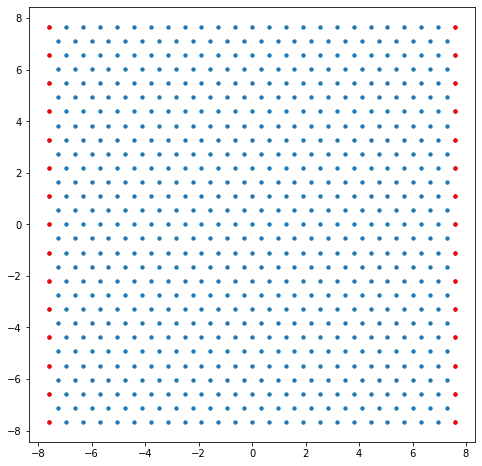

In [105]:
fi = -1    # force index
frame = -1
s = series_simpaths[fi]
print(s)
dumpname = "trajectory1.dump.gz"
result = ReadSim(f"{PROJECT_ROOT}/{s}")
result.read_dump(dumpname=dumpname,readall=False)

fig, ax = plt.subplots(1,1,figsize=(8,8))
# ax.plot(result.dump_x[frame],result.dump_y[frame],"r.")
ax.plot(result.dump_x[0],result.dump_y[0],".")
xmax = np.max(result.dump_x[0])
xmin = np.min(result.dump_x[0])
ymax = np.max(result.dump_y[0])
ymin = np.min(result.dump_y[0])

botmask = (result.dump_z[0]<0)
topmask = (result.dump_z[0]>0)
# xpmask = (result.dump_x[0]>(0.5*wx-0.01*a))
# xmmask = (result.dump_x[0]<(-0.5*wx+0.9*np.sqrt(3)/2*a))
# ypmask = (result.dump_y[0]>(0.5*wy-0.9*np.sqrt(3)/2*a))
# ymmask = (result.dump_y[0]<(-0.5*wy+0.1*a))
xpmask = (result.dump_x[0]>(0.99*xmax))
xmmask = (result.dump_x[0]<(0.99*xmin))
ypmask = (result.dump_y[0]>(0.99*ymax))
ymmask = (result.dump_y[0]<(0.99*ymin))
ax.plot(result.dump_x[0][xpmask],result.dump_y[0][xpmask],"r.")
ax.plot(result.dump_x[0][xmmask],result.dump_y[0][xmmask],"r.")
# ax.plot(result.dump_x[0][ypmask],result.dump_y[0][ypmask],"r.")
# ax.plot(result.dump_x[0][ymmask],result.dump_y[0][ymmask],"r.")
# botmask = result.dump_id[frame]<=(Nbeads)
# topmask = result.dump_id[frame]>(Nbeads)
# ax.plot(result.dump_x[frame][topmask],result.dump_y[frame][topmask],"ko")
# ax.set_xlim(-wx,wx)
# ax.set_ylim(-wx/30,wx/30)

In [48]:
def extents(result,frame=0):
    
    xmax = np.max(result.dump_x[0])
    xmin = np.min(result.dump_x[0])
    ymax = np.max(result.dump_y[0])
    ymin = np.min(result.dump_y[0])
    botmask = (result.dump_z[0]<0)
    topmask = (result.dump_z[0]>0)
    xpmask = (result.dump_x[0]>(0.99*xmax))
    xmmask = (result.dump_x[0]<(0.99*xmin))
    ypmask = (result.dump_y[0]>(0.99*ymax))
    ymmask = (result.dump_y[0]<(0.99*ymin))
    
    xpavg = np.mean(result.dump_x[frame][xpmask])
    xmavg = np.mean(result.dump_x[frame][xmmask])
    ypavg = np.mean(result.dump_y[frame][ypmask])
    ymavg = np.mean(result.dump_y[frame][ymmask])
    zpavg = np.mean(result.dump_z[frame][topmask])
    zmavg = np.mean(result.dump_z[frame][botmask])
    
    x = xpavg-xmavg
    y = ypavg-ymavg
    z = zpavg-zmavg
                   
    return (x,y,z)

In [21]:
s

'data/3d/mesh_characteristics/a-0.130-wx-13.27-wy-13.27/t0-0.130/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-1.000/force-0.1000'

In [20]:
"/Users/kyle/Documents/Code/cgshells/data/3d/mesh_characteristics/a-0.130-wx-13.27-wy-13.27/t0-0.130/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-1.000/force-0.1000"

'/Users/kyle/Documents/Code/cgshells/data/3d/mesh_characteristics/a-0.130-wx-13.27-wy-13.27/t0-0.130/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-1.000/force-0.1000'

In [23]:
f"{PROJECT_ROOT}/{s}"=="/Users/kyle/Documents/Code/cgshells/data/3d/mesh_characteristics/a-0.130-wx-13.27-wy-13.27/t0-0.130/elasticity/kvkh-1.000-kckh-1.000/stretch-x/kh-1.000/force-0.1000"

True

# Read sims and plot

In [106]:
# stretch = "x"

##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 15 * dcore    # mesh width in x 
wy = 15 * dcore    # mesh width in y 
a = 0.632 * dcore #0.130 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
t0 = 1.0 * dcore    # structural thickness
r0 = "flat"   # RMS radius of curvature; set to "flat" for planar plates 
# alpha = -np.pi/4    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

### Elasticity
nuxy = 0.33
nuz = 0.01
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

# kh = kh_list[j]
#         nu = 0.3
#         d = wx/(Nbeads-1)   # bead spacing
# kvkh = 1 #(12 * t0**2 * (1-nu)) / (3 * d**2 * (1-nu) - 4 * t0**2)
# kckh = 1 #(3 * (d**2 + t0**2) * (1-nu))/(2 * t0**2)

t0_list = [1.0]  
forcelist = "all"   # plot all force simulations found in mesh directory
# forcelist = np.linspace(0.001,0.501,100)   # only plot these forces

xstrains = []
ystrains = []
zstrains = []

jobcounter = 0
for i in range(len(t0_list)):
    t0 = t0_list[i]
    kh = 1 
    parentsimpath = f"data/{int(dimension)}d/mesh_characteristics/{mesh_name}/t0-{t0:0.3f}/elasticity/kvkh-{kvkh:0.3f}-kckh-{kckh:0.3f}/stretch-{stretch}/kh-{kh:0.3f}"
    series_simpaths = [] # append simpaths for plotting (i.e. different force values)
    
    if forcelist == "all":

        files = os.listdir(f"{PROJECT_ROOT}/{parentsimpath}")
        for f in files:
            if f[:5] == 'force':
                series_simpaths.append(f"{parentsimpath}/{f}")
    
    else:
        for j in range(len(forcelist)):  
            force  = forcelist[j]
            simpath = f"{parentsimpath}/force-{force:0.4f}" # path to simulation directory (relative to PROJECT_ROOT)
            series_simpaths.append(simpath)
            
    xstrainlist = []
    ystrainlist = []
    zstrainlist = []
    
    for s in series_simpaths:
        dumpname = "trajectory1.dump.gz"
        result = ReadSim(f"{PROJECT_ROOT}/{s}")
        result.read_dump(dumpname=dumpname,readall=False)
        (x0,y0,z0) = extents(result,frame=0)
        (xf,yf,zf) = extents(result,frame=-1)
        xstrain = (xf-x0)/x0
        ystrain = (yf-y0)/y0
        zstrain = (zf-z0)/z0
        xstrainlist.append(xstrain)
        ystrainlist.append(ystrain)
        zstrainlist.append(zstrain)

    xstrains.append(xstrainlist)
    ystrains.append(ystrainlist)
    zstrains.append(zstrainlist)

    
# pratios = np.array(pratios)
# strains = np.array(strains)
    

In [94]:
xstrains

[[0.00387141658113149]]

Text(0, 0.5, 'Poisson Ratio')

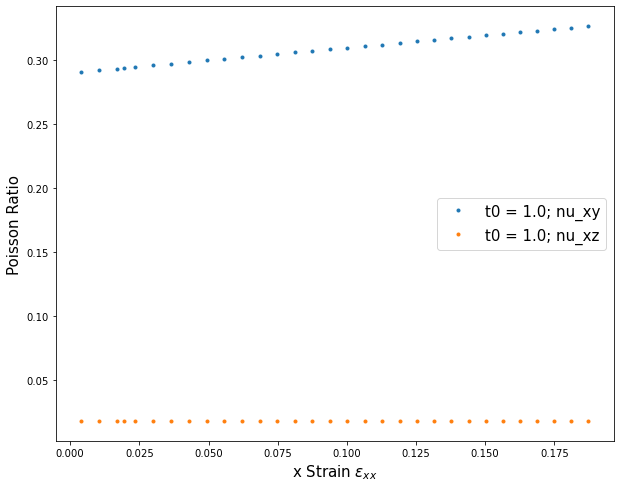

In [107]:
def linfit(x,m,b):
    return m*x+b

maxstrain = 0.05

fig, ax = plt.subplots(1,1,figsize=(10,8))
# nuxy_list = []
for i in range(len(xstrains)):
#     mask = (np.array(strains[i])<=maxstrain)
#     xdata = np.array(strains[i])[mask]
#     ydata = np.array(pratios[i])[mask]
#     params,var = curve_fit(linfit,xdata,ydata)
#     nuxy_list.append(params[1])
    ax.plot(np.array(xstrains[i]),-np.array(ystrains[i])/np.array(xstrains[i]),".",label=f"t0 = {t0_list[i]}; nu_xy")
    ax.plot(np.array(xstrains[i]),-np.array(zstrains[i])/np.array(xstrains[i]),".",label=f"t0 = {t0_list[i]}; nu_xz")

#     ax.plot(np.linspace(0,maxstrain,100),linfit(np.linspace(0,maxstrain,100),params[0],params[1]),"r-",label = f"a = {a_list[i]} (fit) nu = {params[1]:0.3} +/- {np.sqrt(var[1,1]):0.3}")
#     ax.plot(np.linspace(0,maxstrain,100),linfit(np.linspace(0,maxstrain,100),params[0],params[1]),"r-")

# ax.set_xlim(0,1.5)
# ax.set_ylim(0,0.15)
ax.legend(fontsize=15)
ax.set_xlabel("x Strain $\epsilon_{xx}$",fontsize=15)
ax.set_ylabel("Poisson Ratio",fontsize=15)
